## Nonlinear Schrodinger equation with potential

The one-dimensional time-independent nonlinear Schrödinger equation in SI units (with $\hbar$ explicitly) is:

$$
    -\frac{\hbar^2}{2m} \frac{d^2\psi}{dx^2} + V(x)\psi + g|\psi|^2\psi = E\psi
$$

Let's introduce the following dimensionless quantities:

\begin{cases}
    x' = x / L \\
    \psi'(x') = \sqrt{L} \, \psi(L x') \\
    V'(x') = V(L x') / \frac{\hbar ^ 2}{2 m L ^ 2} \\
    E' = E / \frac{\hbar ^ 2}{2 m L ^ 2} \\
    g' = g / \frac{\hbar ^ 2}{2 m L}
\end{cases}

So we get the dimensionless form:

$$
    -\frac{d^2\psi'}{dx'^2} + V'(x')\psi' + g'|\psi'|^2\psi' = E'\psi'
$$

For homogeneous Dirichlet boundary conditions, a numerical solution is given by the following discretized eigenvalue problem:

$$
    \boxed{\bigl[\,T + h^2 \operatorname{diag}(V') + g h^2 \operatorname{diag}(|\psi'|^2)\,\bigr]\,\psi' = E'\,h^2\,\psi', \qquad \psi'_0=\psi'_{N+1}=0}
$$

See NLSE.ipynb

Features:

- Potential V'(x')
- Stopping criteria
- Energy convergence plot

In [1]:
# Importing libraries
import numpy as np
from scipy.linalg import eigh_tridiagonal
from scipy.integrate import trapezoid

import matplotlib.pyplot as plt
plt.style.use('classic')

In [2]:
def solve(state, g, V_func, N = 250, max_iter = 300, tol = 1e-10, min_iter = 50, patience = 25, verbose = True):

    ## Grid ##

    x = np.linspace(0, 1, N + 2)
    h = x[1] - x[0]                      

    ## Potential on interior points ##

    V_int = V_func(x[1:-1])

    ## Construct constant parts of the matrix ##

    d = np.full(N, 2.0) # diagonal of T
    d_pot = d + (h ** 2) * V_int # Add the potential contribution to the diagonal (the h^2 factor)
    e = np.full(N - 1, -1.0) # off-diagonal of T

    ## Initial linear solution (without nonlinearity) ##

    E_start_array, psi_start = eigh_tridiagonal(d_pot, e, select = 'i', select_range = (state, state))
    E_start = E_start_array[0] / (h ** 2)
    psi_start = psi_start.reshape(-1)
    psi_start /= np.sqrt(trapezoid(psi_start ** 2, x[1:-1]))

    ## Iterative nonlinear solution ##

    psi = psi_start.copy()
    E_list = [E_start]
    prev_E = E_start
    consec_small = 0
    converged = False

    for it in range(max_iter):

        V_nonlin = g * h ** 2 * (psi ** 2) # Nonlinear diagonal term: g h^2 |psi|^2
        d_total = d_pot + V_nonlin # Total diagonal: T diagonal + potential + nonlinear

        w, psi_new = eigh_tridiagonal(d_total, e, select = 'i', select_range = (state, state))
        E = w[0] / (h**2)                
        psi_new = psi_new.reshape(-1)
        psi_new /= np.sqrt(trapezoid(psi_new ** 2, x[1:-1]))

        # Relative change in energy
        if prev_E == 0:
            rel_change = abs(E - prev_E)
        else:
            rel_change = abs(E - prev_E) / abs(prev_E)

        E_list.append(E)

        if verbose:
            print(f"Iter {(it + 1):3d}: E' = {E:.3e}   rel. change = {rel_change:.3e}")

        # Convergence check
        if it + 1 >= min_iter:
            if rel_change < tol:
                consec_small += 1
                if consec_small >= patience:
                    converged = True
                    if verbose:
                        print(f"\nConvergence reached after {it + 1} iterations"
                              f"(rel. change {rel_change:.3e} < {tol}).")
                    break
            else:
                consec_small = 0

        psi = psi_new.copy()
        prev_E = E

    if not converged and verbose:
        print(f"\nWarning: did not converge after {max_iter} iterations."
              f"Final rel. change = {rel_change:.3e}")

    ## Plotting ##

    _, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

    # Wavefunctions
    ax1.plot(x[1:-1], psi_start, 'k--', linewidth = 2, label = r"Linear $\psi'$")
    ax1.plot(x[1:-1], psi, 'r-', linewidth = 2, label = r"NLSE $\psi'$")
    ax1.set_xlabel(r"$x'$", fontsize = 14)
    ax1.set_ylabel(r"$\psi'(x')$", fontsize = 14)
    ax1.set_title(f"NLSE solution for state {state}, g' = {g}", fontsize = 12)
    ax1.grid(True, alpha = 0.7)
    ax1.legend(loc = 'best')

    # Energy convergence
    iterations = np.arange(len(E_list))
    ax2.plot(iterations, E_list, 'b-o', linewidth = 1, markersize = 4)
    ax2.set_xlabel("Iteration", fontsize = 14)
    ax2.set_ylabel(r"Energy $E'$", fontsize = 14)
    ax2.set_title("Convergence of energy", fontsize = 12)
    ax2.grid(True, alpha = 0.7)

    plt.tight_layout()
    plt.show()

    print(f"Final energy E' = {E:.3e}")
    return None

Iter   1: E' = -1.328e+01   rel. change = 2.345e+00
Iter   2: E' = -1.503e+01   rel. change = 1.318e-01
Iter   3: E' = -1.563e+01   rel. change = 4.004e-02
Iter   4: E' = -1.585e+01   rel. change = 1.394e-02
Iter   5: E' = -1.593e+01   rel. change = 5.036e-03
Iter   6: E' = -1.596e+01   rel. change = 1.843e-03
Iter   7: E' = -1.597e+01   rel. change = 6.779e-04
Iter   8: E' = -1.597e+01   rel. change = 2.497e-04
Iter   9: E' = -1.597e+01   rel. change = 9.204e-05
Iter  10: E' = -1.597e+01   rel. change = 3.393e-05
Iter  11: E' = -1.597e+01   rel. change = 1.251e-05
Iter  12: E' = -1.597e+01   rel. change = 4.613e-06
Iter  13: E' = -1.597e+01   rel. change = 1.701e-06
Iter  14: E' = -1.597e+01   rel. change = 6.272e-07
Iter  15: E' = -1.597e+01   rel. change = 2.313e-07
Iter  16: E' = -1.597e+01   rel. change = 8.528e-08
Iter  17: E' = -1.597e+01   rel. change = 3.144e-08
Iter  18: E' = -1.597e+01   rel. change = 1.159e-08
Iter  19: E' = -1.597e+01   rel. change = 4.275e-09
Iter  20: E'

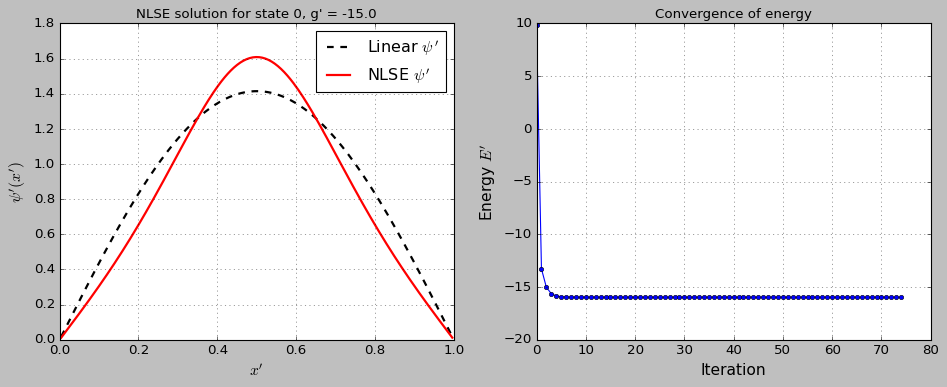

Final energy E' = -1.597e+01


In [3]:
# No potential
V = lambda x_prime: 0
solve(state = 0, g = - 15.0, V_func = V)

Iter   1: E' = -8.015e+01   rel. change = 6.171e-01
Iter   2: E' = -8.335e+01   rel. change = 3.989e-02
Iter   3: E' = -8.435e+01   rel. change = 1.201e-02
Iter   4: E' = -8.473e+01   rel. change = 4.509e-03
Iter   5: E' = -8.490e+01   rel. change = 1.970e-03
Iter   6: E' = -8.498e+01   rel. change = 9.620e-04
Iter   7: E' = -8.502e+01   rel. change = 5.056e-04
Iter   8: E' = -8.505e+01   rel. change = 2.777e-04
Iter   9: E' = -8.506e+01   rel. change = 1.564e-04
Iter  10: E' = -8.507e+01   rel. change = 8.923e-05
Iter  11: E' = -8.507e+01   rel. change = 5.128e-05
Iter  12: E' = -8.508e+01   rel. change = 2.959e-05
Iter  13: E' = -8.508e+01   rel. change = 1.710e-05
Iter  14: E' = -8.508e+01   rel. change = 9.899e-06
Iter  15: E' = -8.508e+01   rel. change = 5.733e-06
Iter  16: E' = -8.508e+01   rel. change = 3.321e-06
Iter  17: E' = -8.508e+01   rel. change = 1.924e-06
Iter  18: E' = -8.508e+01   rel. change = 1.115e-06
Iter  19: E' = -8.508e+01   rel. change = 6.460e-07
Iter  20: E'

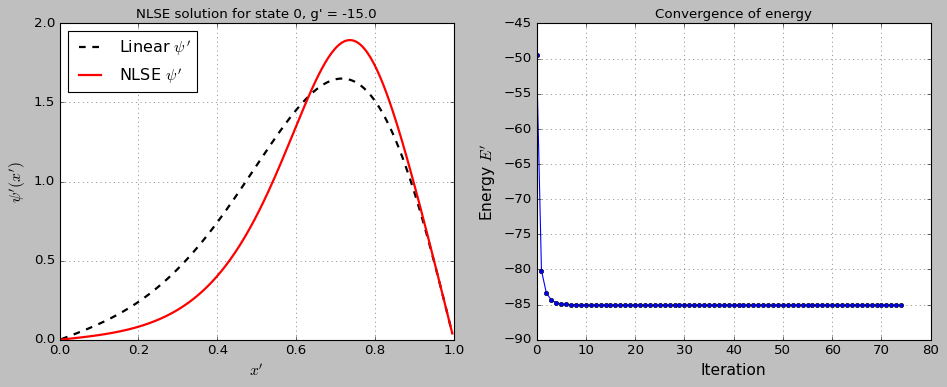

Final energy E' = -8.508e+01


In [4]:
# Linear potential
V = lambda x_prime: - 100 * x_prime
solve(state = 0, g = - 15.0, V_func = V)

Iter   1: E' = -2.077e+01   rel. change = 9.612e+00
Iter   2: E' = -2.126e+01   rel. change = 2.383e-02
Iter   3: E' = -2.145e+01   rel. change = 8.812e-03
Iter   4: E' = -2.153e+01   rel. change = 3.844e-03
Iter   5: E' = -2.157e+01   rel. change = 1.734e-03
Iter   6: E' = -2.158e+01   rel. change = 7.876e-04
Iter   7: E' = -2.159e+01   rel. change = 3.584e-04
Iter   8: E' = -2.160e+01   rel. change = 1.632e-04
Iter   9: E' = -2.160e+01   rel. change = 7.427e-05
Iter  10: E' = -2.160e+01   rel. change = 3.381e-05
Iter  11: E' = -2.160e+01   rel. change = 1.539e-05
Iter  12: E' = -2.160e+01   rel. change = 7.006e-06
Iter  13: E' = -2.160e+01   rel. change = 3.189e-06
Iter  14: E' = -2.160e+01   rel. change = 1.452e-06
Iter  15: E' = -2.160e+01   rel. change = 6.609e-07
Iter  16: E' = -2.160e+01   rel. change = 3.009e-07
Iter  17: E' = -2.160e+01   rel. change = 1.370e-07
Iter  18: E' = -2.160e+01   rel. change = 6.235e-08
Iter  19: E' = -2.160e+01   rel. change = 2.838e-08
Iter  20: E'

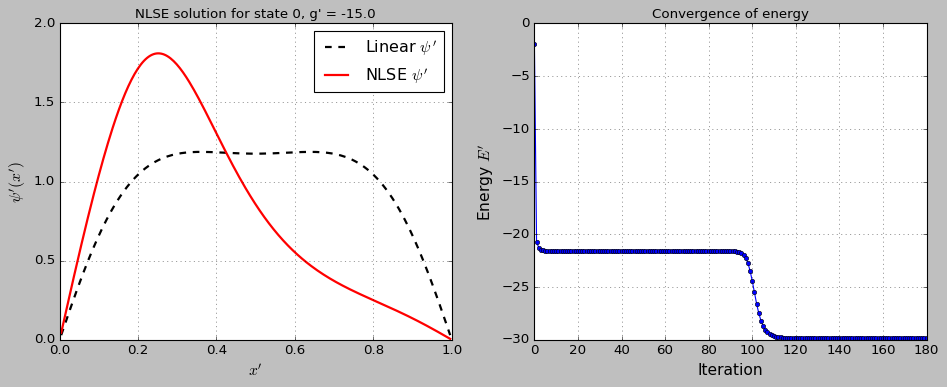

Final energy E' = -2.983e+01


In [5]:
# Harmonic potential
V = lambda x_prime: - 300 * (x_prime - 0.5) ** 2
solve(state = 0, g = - 15.0, V_func = V)